# Final Project

#### Imports

In [42]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import pandas as pd
import string
import time
import os
from datetime import datetime

# Use GPU if available, fall back to CPU otherwise
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.backends.cudnn.benchmark = True

NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = device.type == "cuda"

Using device: cuda


### Task A - Initial Setup
#### Loading Dataset
b) Download the EMNIST dataset. Note that it contains 6 variants, so called splits, which differ in size and contents. For the first half of the project, you should be using the ‘letters’ split. After loading the dataset, plot a random selection of image samples and the corresponding labels (similar to Figure 1.).

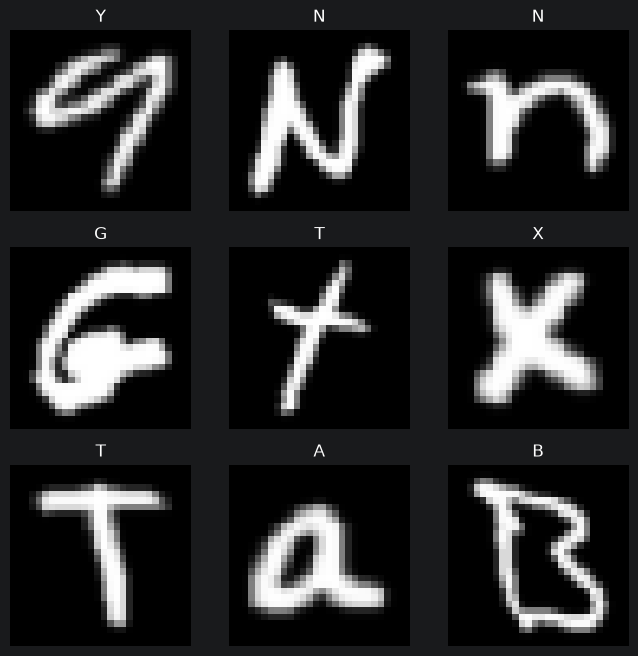

In [43]:
training_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

letters = ["N/A"] + list(string.ascii_uppercase)

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(letters[label])
    plt.axis("off")
    plt.imshow(img.squeeze().T, cmap="gray")
plt.show()

#### Basic learning functionality
c) Implement a program that defines the simple CNN model depicted in see Figure 2. and trains letter classification on the loaded dataset from step b). Implement two functions that use the given model and respective dataset for training and testing. Using cross entropy loss can be a convenient loss function, since it does not require normalized input. In addition, your program should visualize (plot) the training loss and record the total training time.

##### Create Data Loader

In [44]:
batch_size = 512

training_loader = DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)


##### Define CNN

In [45]:
class Model:
    def __init__(self, model, learning_rate, batch_size, description="simple-cnn", device=device, label_offset=1):
        self.device = device
        self.model = model.to(self.device)
        self.criterion = torch.nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.layers = sum(1 for _ in self.model.modules()) - 1
        self.description = description
        self.label_offset = label_offset

    # TRAINING FUNCTION
    def train(self, loader):
        self.model.train()

        running_loss = 0
        batch_losses = []

        for images, labels in loader:
            images = images.to(self.device)
            labels = labels.to(self.device) - self.label_offset

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            batch_losses.append(loss.item())

        average_loss = running_loss / len(loader)

        return average_loss, batch_losses

    # TESTING FUNCTION
    def test(self, loader):
        self.model.eval()

        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                labels = labels.to(self.device) - self.label_offset

                outputs = self.model(images)
                predictions = outputs.argmax(dim=1)

                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        accuracy = 100 * correct / total
        return accuracy

    # SAVE MODEL HELPER FUNCTION
    def save_model(self, loss_history=None, epochs=0, accuracy=None, model_dir="models", figs_dir="figs", show_plot=False):
        os.makedirs(model_dir, exist_ok=True)
        os.makedirs(figs_dir, exist_ok=True)

        timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
        acc_part = f"_acc{accuracy:.2f}" if accuracy is not None else ""

        base_name = (
            f"cnn_{self.description}"
            f"_epo{epochs}"
            f"_lr{self.learning_rate}"
            f"_bs{self.batch_size}"
            f"_lay{self.layers}"
            f"_optAdam"
            f"{acc_part}"
            f"_{timestamp}"
        )

        model_path = os.path.join(model_dir, base_name + ".pth")
        torch.save(self.model.state_dict(), model_path)
        print(f"Model saved to: {model_path}")

        if loss_history is not None and epochs != 0:
            fig_path = os.path.join(figs_dir, base_name + "_loss_history.png")
            save_loss_plot(loss_history, filename=fig_path, show_plot=show_plot)
            print(f"Plot saved to: {fig_path}")

        return model_path

##### Training Loop

In [46]:
def training_loop(model, epochs, train_loader, test_loader, verbose=True):
    loss_history = []

    start_time = time.time()

    for epoch in range(epochs):
        avg_loss, batch_losses = model.train(train_loader)
        loss_history.append(batch_losses)

        accuracy = model.test(test_loader)

        if verbose:
            print(
                f"Epoch {epoch+1}/{epochs}  "
                f"Loss {avg_loss:.4f}  "
                f"Accuracy {accuracy:.2f}%"
            )

    training_time = time.time() - start_time

    if verbose:
        print(f"\nTraining time: {training_time:.2f} seconds")

    return loss_history, training_time


##### Training Loss Plot

In [47]:
def save_loss_plot(loss_history, filename, show_plot=False):
    plt.figure(figsize=(8, 5))

    for epoch, losses in enumerate(loss_history):
        plt.plot(losses, label=f"Epoch {epoch+1}")

    plt.xlabel("Batch")
    plt.ylabel("Loss")
    plt.title("Training Loss per Batch")
    plt.legend()
    plt.savefig(filename)

    if show_plot:
        plt.show()
    else:
        plt.close()


#### Define Simple CNN Model

In [48]:
def make_simple_architecture():
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=8 * 14 * 14, out_features=26),
    )

### Task B
#### b) Adding more Layers


In [49]:
def make_architecture_1():
    # Two convolutions before a single pool at the end ("pooling-at-end")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.Conv2d(in_channels=8, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=8 * 14 * 14, out_features=26),
    )

In [50]:
def make_architecture_2():
    # Pool after each conv ("pooling-between")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=16 * 7 * 7, out_features=26),
    )

In [51]:
def make_architecture_3():
    # Adds a hidden fully-connected layer before the output ("more-layers")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=16 * 7 * 7, out_features=64),
        torch.nn.ReLU(),
        torch.nn.Linear(in_features=64, out_features=26),
    )

#### c) number of feature maps and the Size of the convolution Kernel

In [52]:
def make_architecture_4():
    # More feature maps: 16 -> 32 instead of 8 -> 16 ("more-feature-maps")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=32 * 7 * 7, out_features=64),
        torch.nn.ReLU(),
        torch.nn.Linear(in_features=64, out_features=26),
    )

In [53]:
def make_architecture_5():
    # Larger convolution kernels: 5x5 instead of 3x3 ("larger-kernels")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=7, padding=3),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=7, padding=3),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=16 * 7 * 7, out_features=64),
        torch.nn.ReLU(),
        torch.nn.Linear(in_features=64, out_features=26),
    )


##### Automated Experiments

In [54]:
experiments = [
    # --- Architecture comparison (task b/c) ---
    {"name": "simple-cnn",        "arch_fn": make_simple_architecture, "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "pooling-at-end",    "arch_fn": make_architecture_1,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "pooling-between",   "arch_fn": make_architecture_2,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "more-layers",       "arch_fn": make_architecture_3,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "more-feature-maps", "arch_fn": make_architecture_4,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "larger-kernels",    "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 512, "epochs": 5},

    # --- Learning-rate sweep using architecture 5 as base (best one currently, afaik) ---
    {"name": "lr-0.01",           "arch_fn": make_architecture_5,      "lr": 0.01,   "batch_size": 512, "epochs": 5},
    {"name": "lr-0.001",          "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "lr-0.0001",         "arch_fn": make_architecture_5,      "lr": 0.0001, "batch_size": 512, "epochs": 5},

    # --- Batch-size sweep ---
    {"name": "batch-64",          "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 64,  "epochs": 5},
    {"name": "batch-256",         "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 256, "epochs": 5},

    # --- Epoch sweep ---
    {"name": "epochs-3",          "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 512, "epochs": 3},
    {"name": "epochs-10",         "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 512, "epochs": 10},

    {"name": "b-64-ep-10","arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 64, "epochs": 10},

]

print(f"{len(experiments)} experiments queued.")


14 experiments queued.


In [55]:
results = []

for cfg in experiments:
    print(f"\n=== Running experiment: {cfg['name']} ===")

    architecture = cfg["arch_fn"]()
    exp_train_loader = DataLoader(
            training_data, batch_size=cfg["batch_size"], shuffle=True,
            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0,
    )
    exp_test_loader = DataLoader(
            test_data, batch_size=cfg["batch_size"], shuffle=False,
            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0,
    )

    model = Model(
        architecture,
        learning_rate=cfg["lr"],
        batch_size=cfg["batch_size"],
        description=cfg["name"],
    )

    loss_history, training_time = training_loop(
        model,
        epochs=cfg["epochs"],
        train_loader=exp_train_loader,
        test_loader=exp_test_loader,
    )
    accuracy = model.test(exp_test_loader)

    results.append({
        "name": cfg["name"],
        "learning_rate": cfg["lr"],
        "batch_size": cfg["batch_size"],
        "epochs": cfg["epochs"],
        "layers": model.layers,
        "accuracy": accuracy,
        "training_time_sec": training_time,
        "model": model,
        "loss_history": loss_history,
    })

results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ("model", "loss_history")} for r in results]
).sort_values("accuracy", ascending=False).reset_index(drop=True)

results_df



=== Running experiment: simple-cnn ===
Epoch 1/5  Loss 1.2990  Accuracy 72.00%
Epoch 2/5  Loss 0.8788  Accuracy 77.25%
Epoch 3/5  Loss 0.6979  Accuracy 82.09%
Epoch 4/5  Loss 0.5644  Accuracy 84.61%
Epoch 5/5  Loss 0.4817  Accuracy 86.31%

Training time: 42.80 seconds

=== Running experiment: pooling-at-end ===
Epoch 1/5  Loss 1.0502  Accuracy 84.01%
Epoch 2/5  Loss 0.4492  Accuracy 87.71%
Epoch 3/5  Loss 0.3707  Accuracy 88.89%
Epoch 4/5  Loss 0.3334  Accuracy 89.47%
Epoch 5/5  Loss 0.3100  Accuracy 89.68%

Training time: 45.40 seconds

=== Running experiment: pooling-between ===
Epoch 1/5  Loss 1.1634  Accuracy 81.85%
Epoch 2/5  Loss 0.4812  Accuracy 87.50%
Epoch 3/5  Loss 0.3743  Accuracy 88.60%
Epoch 4/5  Loss 0.3302  Accuracy 89.62%
Epoch 5/5  Loss 0.3056  Accuracy 90.03%

Training time: 43.08 seconds

=== Running experiment: more-layers ===
Epoch 1/5  Loss 1.2414  Accuracy 80.50%
Epoch 2/5  Loss 0.5256  Accuracy 86.52%
Epoch 3/5  Loss 0.4037  Accuracy 88.38%
Epoch 4/5  Loss 0.34

,name,learning_rate,batch_size,epochs,layers,accuracy,training_time_sec
0,b-64-ep-10,0.0010,64,10,10,93.216346,135.124238
1,epochs-10,0.0010,512,10,10,92.504808,101.004859
2,batch-64,0.0010,64,5,10,92.471154,64.654000
3,lr-0.01,0.0100,512,5,10,92.370192,49.450490
4,more-feature-maps,0.0010,512,5,10,91.562500,47.389905
5,larger-kernels,0.0010,512,5,10,91.495192,49.132862
6,batch-256,0.0010,256,5,10,91.370192,54.891049
7,lr-0.001,0.0010,512,5,10,90.394231,49.893078
8,pooling-between,0.0010,512,5,8,90.028846,43.077363
9,epochs-3,0.0010,512,3,10,89.947115,33.228524


##### Visual Comparison

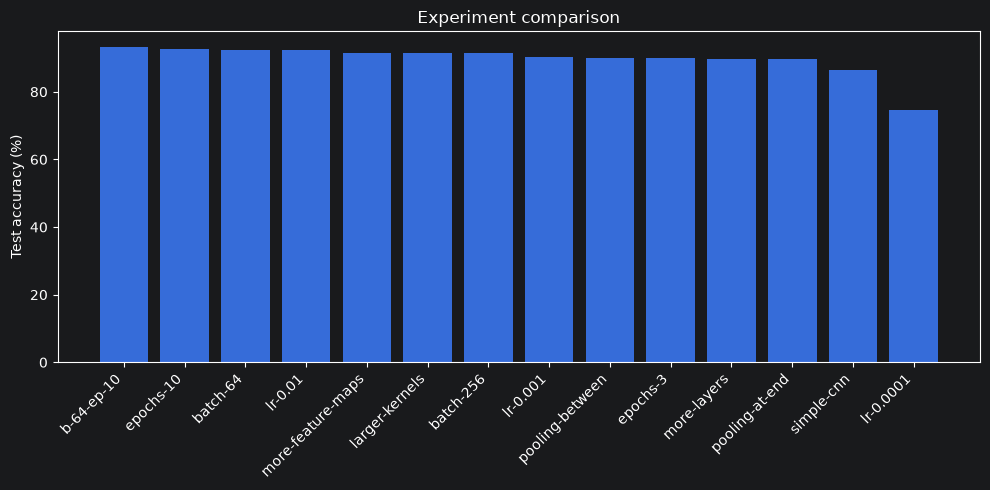

In [56]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["name"], results_df["accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test accuracy (%)")
plt.title("Experiment comparison")
plt.tight_layout()
plt.show()


##### e) Save the best performer

Best experiment: b-64-ep-10
  Accuracy:      93.22%
  Learning rate: 0.001
  Batch size:    64
  Epochs:        10
  Training time: 135.12s
Model saved to: models/cnn_b-64-ep-10_epo10_lr0.001_bs64_lay10_optAdam_acc93.22_20260812-140704.pth


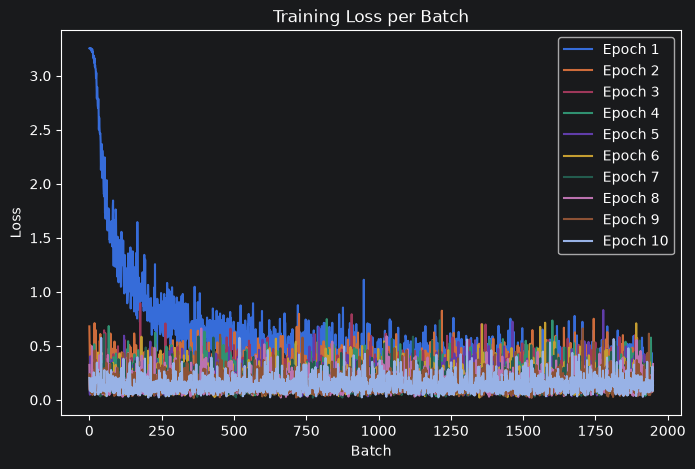

Plot saved to: figs/cnn_b-64-ep-10_epo10_lr0.001_bs64_lay10_optAdam_acc93.22_20260812-140704_loss_history.png


In [57]:
best = max(results, key=lambda r: r["accuracy"])

print(f"Best experiment: {best['name']}")
print(f"  Accuracy:      {best['accuracy']:.2f}%")
print(f"  Learning rate: {best['learning_rate']}")
print(f"  Batch size:    {best['batch_size']}")
print(f"  Epochs:        {best['epochs']}")
print(f"  Training time: {best['training_time_sec']:.2f}s")

best_model_path = best["model"].save_model(
    loss_history=best["loss_history"],
    epochs=best["epochs"],
    accuracy=best["accuracy"],
    show_plot=True,
)


### Task C - Transfer Learning
Transfer learning is a technique that allows faster training by utilizing existing models pre-trained on large datasets. To simulate this behavior, your task is to train a model to for digit classification (only 10 classes) on the basis of an existing letter classifier. You can find an example for transfer learning in [4].
#### a) MNIST Dataset
Download the **MNIST** training and test datasets or, alternately, use the **‘digits’ split of the EMNIST** dataset, which contain grayscale images of the digits 0-9.

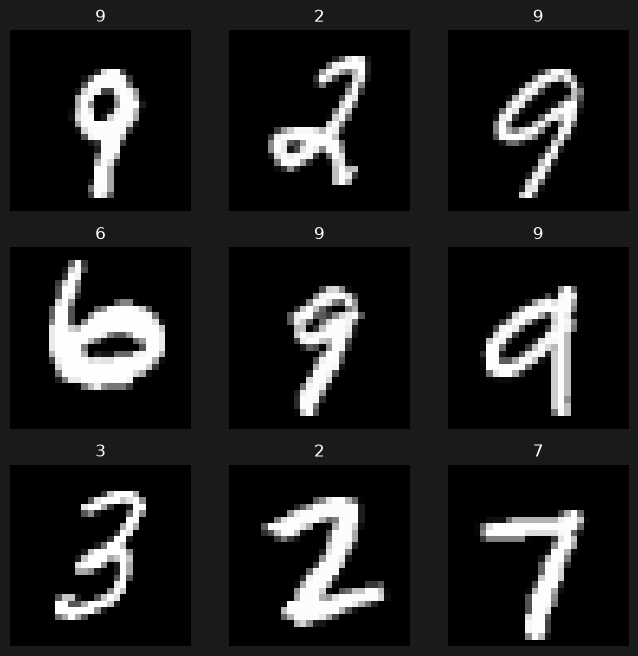

In [58]:
training_data_MNIST = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data_MNIST = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)


figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data_MNIST), size=(1,)).item()
    img, label = training_data_MNIST[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

#### b) Load Best Performing Model
Load your **best performing letter classification model** from task B e). Make sure that you are loading the complete state dictionary of the previously saved model.

In [59]:
best_architecture = next(
    config["arch_fn"]()
    for config in experiments
    if config["name"] == best["name"]
)

# Load the complete state dictionary
state_dict = torch.load(
    best_model_path,
    map_location=device,
    weights_only=True
)

best_architecture.load_state_dict(state_dict)

best_architecture = best_architecture.to(device)

best_architecture.eval()

print("Best letter classification model loaded successfully.")

Best letter classification model loaded successfully.


#### c) Final Fully Connected Layer Match Output Classes
Modify the architecture of your model such that the final fully connected layer matches the expected number of output classes. There should be no further modifications of the loaded pre-trained model.

In [60]:
old_layer = best_architecture[-1]

best_architecture[-1] = torch.nn.Linear(
    in_features=old_layer.in_features,
    out_features=10
)

print(best_architecture)

Sequential(
  (0): Conv2d(1, 8, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=784, out_features=64, bias=True)
  (8): ReLU()
  (9): Linear(in_features=64, out_features=10, bias=True)
)


#### d) Transfer Learning
Conduct **transfer learning** by freezing all layers except the last one during training. The goal is to train only the weights of the final fully connected layer of your model.

In [61]:
for param in best_architecture.parameters():
    param.requires_grad = False

final_layer = best_architecture[-1]

for param in final_layer.parameters():
    param.requires_grad = True

print("Trainable parameters:")
for name, param in best_architecture.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.numel():,}")

total_parameters = sum(param.numel() for param in best_architecture.parameters())
trainable_parameters = sum(param.numel() for param in best_architecture.parameters() if param.requires_grad)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Frozen parameters: {total_parameters - trainable_parameters:,}")


mnist_model = Model(
    best_architecture,
    learning_rate=0.001,
    batch_size=64,
    description="transfer-learning-mnist",
    label_offset=0
)

mnist_model.optimizer = torch.optim.Adam(
    filter(lambda param: param.requires_grad, mnist_model.model.parameters()),
    lr=0.001
)


mnist_training_loader = DataLoader(
    training_data_MNIST,
    batch_size=batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

mnist_test_loader = DataLoader(
    test_data_MNIST,
    batch_size=batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

loss_history, training_time = training_loop(
    mnist_model,
    epochs=10,
    train_loader=mnist_training_loader,
    test_loader=mnist_test_loader,
)

accuracy = mnist_model.test(mnist_test_loader)

print(f"MNIST transfer-learning accuracy: {accuracy:.2f}%")

Trainable parameters:
9.weight: 640
9.bias: 10
Total parameters: 57,578
Trainable parameters: 650
Frozen parameters: 56,928
Epoch 1/10  Loss 1.8564  Accuracy 83.58%
Epoch 2/10  Loss 0.4559  Accuracy 91.27%
Epoch 3/10  Loss 0.3203  Accuracy 92.88%
Epoch 4/10  Loss 0.2701  Accuracy 93.63%
Epoch 5/10  Loss 0.2440  Accuracy 93.94%
Epoch 6/10  Loss 0.2265  Accuracy 94.17%
Epoch 7/10  Loss 0.2148  Accuracy 94.34%
Epoch 8/10  Loss 0.2055  Accuracy 94.39%
Epoch 9/10  Loss 0.1990  Accuracy 94.62%
Epoch 10/10  Loss 0.1934  Accuracy 94.66%

Training time: 48.02 seconds
MNIST transfer-learning accuracy: 94.66%
